In [14]:
import os
import glob
from pathlib import Path
import kagglehub
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# 1. Download Dataset via Kagglehub
print("Downloading 'FORS-EMG: A Novel sEMG Dataset'...")
try:
    path = kagglehub.dataset_download("ummerummanchaity/fors-emg-a-novel-semg-dataset")
    dataset_dir = Path(path)
    print(f"\n[SUCCESS] Dataset downloaded to: {dataset_dir}")
except Exception as e:
    print(f"\n[ERROR] Could not download dataset automatically: {e}")
    # Fallback to local working directory if running offline
    dataset_dir = Path("./fors-emg-a-novel-semg-dataset")

# 2. Inspect Dataset Directory Contents
all_files = list(dataset_dir.rglob("*"))
file_types = {}
for f in all_files:
    if f.is_file():
        ext = f.suffix.lower() or "no_extension"
        file_types[ext] = file_types.get(ext, 0) + 1

# Display Dataset Overview Table
print("\n" + "="*50)
print("     FORS-EMG DATASET DIRECTORY SUMMARY     ")
print("="*50)
print(f"Total Items Found : {len(all_files)}")
print(f"Total Files       : {sum(file_types.values())}")
print("-" * 50)
print("File Format Breakdown:")
for ext, count in file_types.items():
    print(f"  • {ext:<12} : {count} file(s)")
print("="*50)


[SUCCESS] Dataset downloaded to: /kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset

     FORS-EMG DATASET DIRECTORY SUMMARY     
Total Items Found : 3510
Total Files       : 3427
--------------------------------------------------
File Format Breakdown:
  • .txt         : 3 file(s)
  • .pdf         : 1 file(s)
  • .csv         : 1 file(s)
  • .jpg         : 1 file(s)
  • .png         : 1 file(s)
  • .mat         : 3420 file(s)


In [15]:
import re
import pandas as pd

# List to store metadata per file
file_metadata = []

# Scan all .mat files in the dataset directory
mat_filepaths = list(dataset_dir.rglob("*.mat"))

print(f"Scanning {len(mat_filepaths)} .mat files for metadata...")

for file_path in mat_filepaths:
    rel_path = file_path.relative_to(dataset_dir)
    path_parts = rel_path.parts
    
    # Standard FORS-EMG path structure: [Orientation]/[Subject]/[Filename.mat]
    # Fallback default values if structure varies slightly
    orientation = "Unknown"
    subject = "Unknown"
    
    for part in path_parts:
        part_lower = part.lower()
        if any(o in part_lower for o in ['supination', 'pronation', 'rest', 'neutral']):
            orientation = part.capitalize()
        elif 'sub' in part_lower or 'subject' in part_lower or part_lower.startswith('s'):
            subject = part
            
    filename = file_path.stem
    
    # Parse Gesture Name and Trial Number from filename (e.g., 'Peace_trial1', 'Thumb_up_3')
    # Regex splits name and numeric repetition trailing identifier
    match = re.match(r"^([A-Za-z\s_-]+?)[_ -]?(\d+)?$", filename)
    if match:
        gesture = match.group(1).replace("_", " ").strip().title()
        trial = match.group(2) if match.group(2) else "1"
    else:
        gesture = filename.title()
        trial = "1"

    file_metadata.append({
        "filepath": str(file_path),
        "filename": file_path.name,
        "extension": file_path.suffix.lower(),
        "orientation": orientation,
        "subject": subject,
        "gesture": gesture,
        "trial": trial,
        "file_size_kb": round(file_path.stat().st_size / 1024, 2)
    })

# Convert to Pandas DataFrame
df_files = pd.DataFrame(file_metadata)

# Display Summary
print("\n" + "="*55)
print("             METADATA EXTRACTION SUMMARY             ")
print("="*55)
print(f"Total .mat Files Cataloged : {len(df_files)}")
print(f"Unique Forearm Orientations: {df_files['orientation'].nunique()} -> {list(df_files['orientation'].unique())}")
print(f"Unique Subjects            : {df_files['subject'].nunique()}")
print(f"Unique Gestures            : {df_files['gesture'].nunique()}")
print("="*55)

# Preview top 5 rows
print("\nDataFrame Preview (First 5 Rows):")
df_files[['filename', 'orientation', 'gesture', 'trial', 'file_size_kb']].head()

Scanning 3420 .mat files for metadata...

             METADATA EXTRACTION SUMMARY             
Total .mat Files Cataloged : 3420
Unique Forearm Orientations: 3 -> ['Supination', 'Rest', 'Pronation']
Unique Subjects            : 19
Unique Gestures            : 12

DataFrame Preview (First 5 Rows):


,filename,orientation,gesture,trial,file_size_kb
0,Peace-4.mat,Supination,Peace,4,81.00
1,Hand_Close-1.mat,Supination,Hand Close,1,89.30
2,Radial_Deviation-5.mat,Supination,Radial Deviation,5,101.66
3,Wrist_Flexion-3.mat,Supination,Wrist Flexion,3,85.83
4,Hand_Close-2.mat,Supination,Hand Close,2,89.49


/tmp/ipykernel_58/2700738939.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


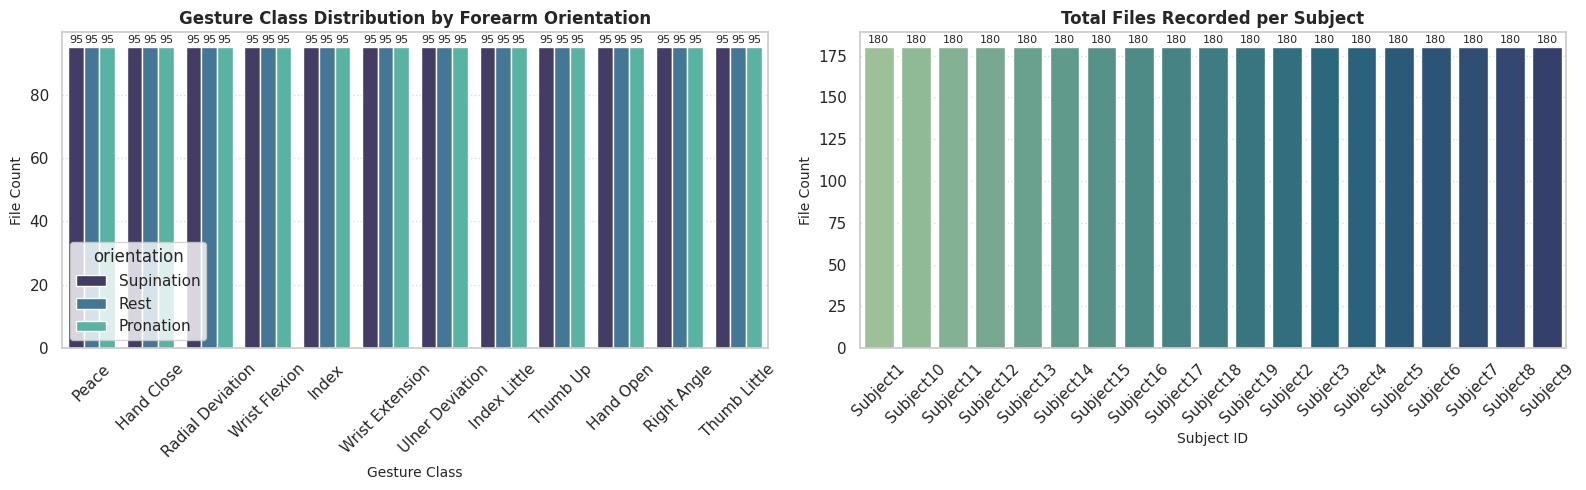

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for dataset distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Gesture Count Distribution across Forearm Orientations
sns.countplot(
    data=df_files, 
    x="gesture", 
    hue="orientation", 
    ax=axes[0], 
    palette="mako"
)
axes[0].set_title("Gesture Class Distribution by Forearm Orientation", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Gesture Class", fontsize=10)
axes[0].set_ylabel("File Count", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle=":", alpha=0.7)

# Add value annotations on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=8, padding=2)

# Plot 2: Total Files Recorded per Subject
sns.countplot(
    data=df_files, 
    x="subject", 
    ax=axes[1], 
    palette="crest",
    order=sorted(df_files["subject"].unique())
)
axes[1].set_title("Total Files Recorded per Subject", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Subject ID", fontsize=10)
axes[1].set_ylabel("File Count", fontsize=10)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle=":", alpha=0.7)

# Add value annotations on top of bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import scipy.io as sio

def inspect_mat_file(file_path):
    """
    Loads a .mat file, extracts data dictionary keys, array dimensions,
    and estimates the sampling rate (fs) and duration.
    """
    mat_dict = sio.loadmat(file_path)
    
    # Filter out MATLAB internal headers
    data_keys = [k for k in mat_dict.keys() if not k.startswith('__')]
    
    # Identify signal array key (assumes largest numpy array)
    signal_key = max(data_keys, key=lambda k: mat_dict[k].size if isinstance(mat_dict[k], np.ndarray) else 0)
    raw_signal = np.array(mat_dict[signal_key], dtype=np.float64)
    
    # Standardize orientation to (Samples, Channels)
    if raw_signal.shape[0] < raw_signal.shape[1]:
        raw_signal = raw_signal.T
        
    num_samples, num_channels = raw_signal.shape
    
    # Dynamic sampling rate detection with default fallback
    fs = 1000.0  # Default 1000 Hz for sEMG standard
    if 'fs' in mat_dict:
        fs = float(np.squeeze(mat_dict['fs']))
    elif 'time' in mat_dict:
        t = np.squeeze(mat_dict['time'])
        fs = float(1.0 / np.mean(np.diff(t)))

    duration = num_samples / fs
    
    return {
        "dictionary_keys": data_keys,
        "signal_key": signal_key,
        "raw_shape": raw_signal.shape,
        "num_samples": num_samples,
        "num_channels": num_channels,
        "fs": fs,
        "duration_sec": duration,
        "data_type": raw_signal.dtype,
        "signal_matrix": raw_signal
    }

# Select first file from the dataset
sample_file_path = df_files['filepath'].iloc[0]
sample_info = inspect_mat_file(sample_file_path)

# Display MATLAB Inspection Table
print("="*60)
print("             MATLAB (.mat) FILE STRUCTURE AUDIT             ")
print("="*60)
print(f"Sample File Path   : {df_files['filename'].iloc[0]}")
print(f"Internal Keys Found: {sample_info['dictionary_keys']}")
print(f"Extracted Array Key: '{sample_info['signal_key']}'")
print(f"Data Matrix Shape  : {sample_info['raw_shape']} (Samples x Channels)")
print(f"Channel Count      : {sample_info['num_channels']} Channels")
print(f"Sample Rate (fs)   : {sample_info['fs']} Hz")
print(f"Recording Duration : {sample_info['duration_sec']:.2f} seconds")
print(f"Signal Data Type   : {sample_info['data_type']}")
print("="*60)

# Display First 5 Rows of Signal Data
print("\nSignal Array Data Snippet (First 5 Time-steps):")
print(sample_info['signal_matrix'][:5, :])

             MATLAB (.mat) FILE STRUCTURE AUDIT             
Sample File Path   : Peace-4.mat
Internal Keys Found: ['value']
Extracted Array Key: 'value'
Data Matrix Shape  : (8000, 8) (Samples x Channels)
Channel Count      : 8 Channels
Sample Rate (fs)   : 1000.0 Hz
Recording Duration : 8.00 seconds
Signal Data Type   : float64

Signal Array Data Snippet (First 5 Time-steps):
[[ 0.00488281  0.          0.00976562  0.         -0.00488281 -0.00976562
   0.00488281  0.00488281]
 [ 0.00488281  0.         -0.00976562  0.00488281 -0.00488281  0.
   0.00488281  0.        ]
 [-0.00488281 -0.00488281 -0.00976562 -0.00488281  0.00488281  0.
   0.00488281  0.00488281]
 [ 0.00488281  0.00488281  0.00976562  0.00976562 -0.00488281 -0.00488281
   0.00488281  0.00976562]
 [ 0.00976562  0.00976562  0.          0.00488281  0.00488281  0.00488281
   0.          0.00488281]]


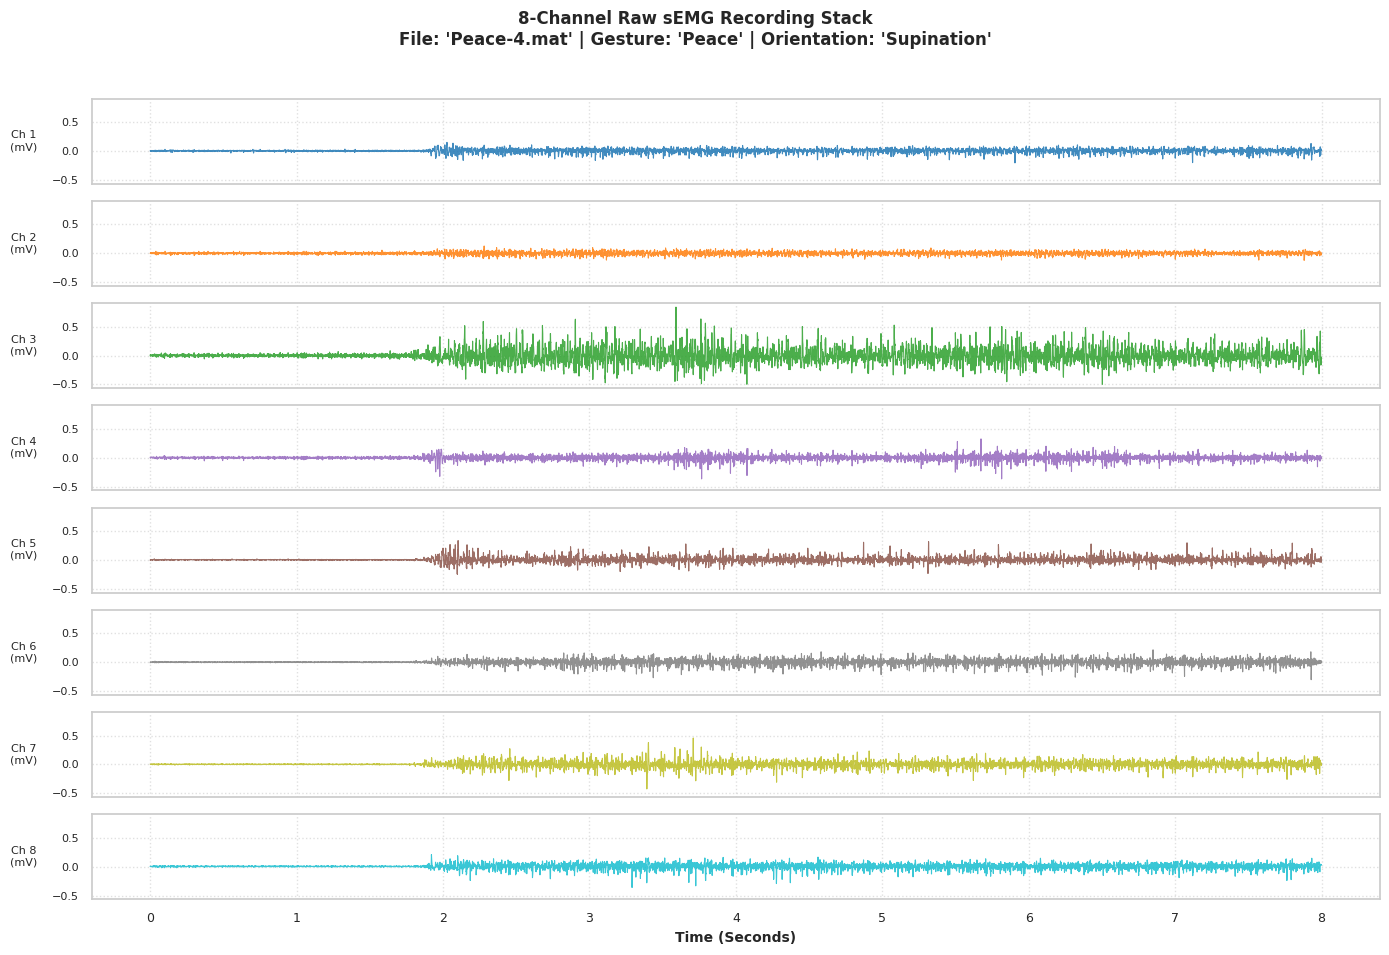

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve raw signal data and metadata from sample_info (Cell 4)
raw_signal = sample_info['signal_matrix']
fs = sample_info['fs']
num_samples, num_channels = raw_signal.shape
time_axis = np.arange(num_samples) / fs

sample_filename = df_files['filename'].iloc[0]
sample_gesture = df_files['gesture'].iloc[0]
sample_orientation = df_files['orientation'].iloc[0]

# Create stacked multi-channel signal subplot
fig, axes = plt.subplots(num_channels, 1, figsize=(14, 10), sharex=True, sharey=True)

# Distinct color palette for channels
colors = plt.cm.tab10(np.linspace(0, 1, num_channels))

for ch in range(num_channels):
    axes[ch].plot(time_axis, raw_signal[:, ch], color=colors[ch], linewidth=0.8, alpha=0.85)
    axes[ch].set_ylabel(f"Ch {ch+1}\n(mV)", fontsize=8, rotation=0, labelpad=20, va="center")
    axes[ch].grid(True, linestyle=":", alpha=0.6)
    axes[ch].tick_params(axis="y", labelsize=8)

# Format bottom x-axis
axes[-1].set_xlabel("Time (Seconds)", fontsize=10, fontweight="bold")
axes[-1].tick_params(axis="x", labelsize=9)

# Figure Header
plt.suptitle(
    f"8-Channel Raw sEMG Recording Stack\nFile: '{sample_filename}' | Gesture: '{sample_gesture}' | Orientation: '{sample_orientation}'",
    fontsize=12,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

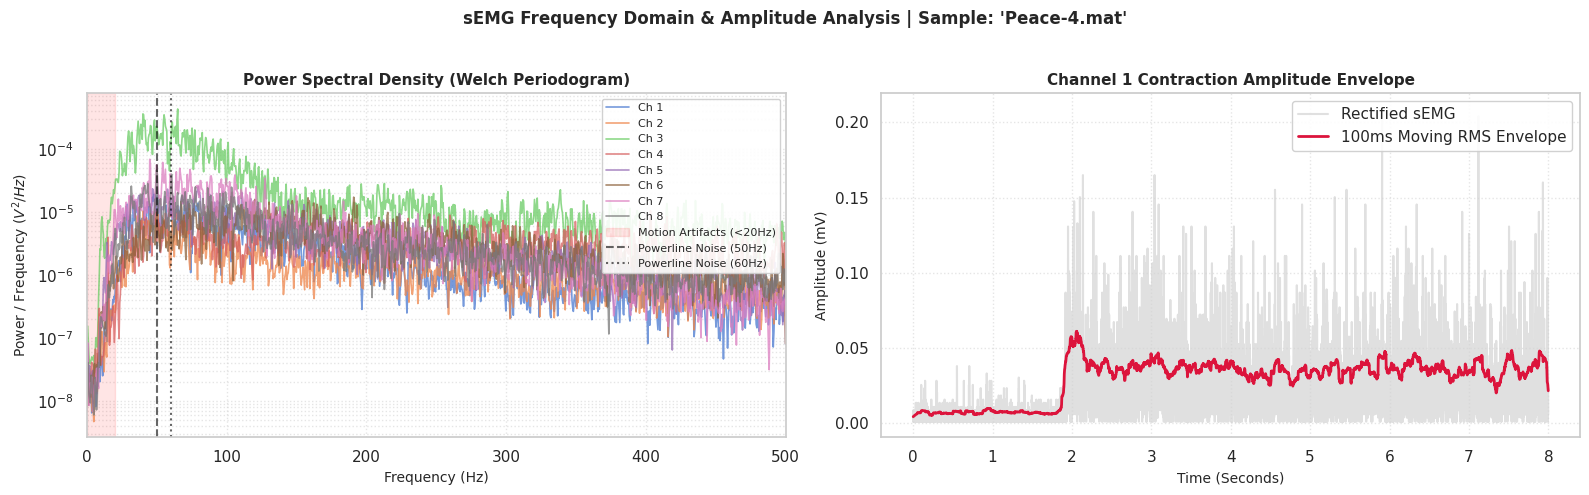

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Set up subplots: Power Spectral Density (Left) and RMS Envelope (Right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------------------------------------------
# 1. Power Spectral Density (PSD) Analysis
# -------------------------------------------------------------
for ch in range(num_channels):
    freqs, psd = welch(raw_signal[:, ch], fs=fs, nperseg=min(2048, num_samples))
    ax1.semilogy(freqs, psd, label=f'Ch {ch+1}', alpha=0.75, linewidth=1.2)

# Highlight domain-specific EMG frequency regions
ax1.axvspan(0, 20, color='red', alpha=0.1, label='Motion Artifacts (<20Hz)')
ax1.axvline(50, color='black', linestyle='--', alpha=0.6, label='Powerline Noise (50Hz)')
ax1.axvline(60, color='black', linestyle=':', alpha=0.6, label='Powerline Noise (60Hz)')

ax1.set_xlim(0, fs / 2)  # Nyquist limit
ax1.set_title("Power Spectral Density (Welch Periodogram)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Frequency (Hz)", fontsize=10)
ax1.set_ylabel("Power / Frequency ($V^2/Hz$)", fontsize=10)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)
ax1.legend(fontsize=8, loc='upper right', framealpha=0.9)

# -------------------------------------------------------------
# 2. Rectified Signal & Moving RMS Envelope (Channel 1 Example)
# -------------------------------------------------------------
selected_ch = 0
ch_data = raw_signal[:, selected_ch] - np.mean(raw_signal[:, selected_ch])  # DC offset correction

# Calculate 100ms Moving Root Mean Square (RMS) Envelope
window_len = int(0.100 * fs)  # 100ms window (100 samples at 1000Hz)
rms_env = np.sqrt(np.convolve(ch_data**2, np.ones(window_len) / window_len, mode='same'))

ax2.plot(time_axis, np.abs(ch_data), color='lightgray', label='Rectified sEMG', alpha=0.7)
ax2.plot(time_axis, rms_env, color='crimson', linewidth=2, label='100ms Moving RMS Envelope')

ax2.set_title(f"Channel {selected_ch+1} Contraction Amplitude Envelope", fontsize=11, fontweight="bold")
ax2.set_xlabel("Time (Seconds)", fontsize=10)
ax2.set_ylabel("Amplitude (mV)", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.9)

plt.suptitle(
    f"sEMG Frequency Domain & Amplitude Analysis | Sample: '{sample_filename}'",
    fontsize=12,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Computing global sEMG amplitude metrics across full dataset...

             GLOBAL sEMG STATISTICAL SUMMARY BY ORIENTATION             
orientation  Files  Mean_RMS  Std_RMS  Max_Peak
  Pronation   1140  0.099336 0.042363  2.529297
       Rest   1140  0.094298 0.043368  2.553711
 Supination   1140  0.090719 0.042267  2.529297


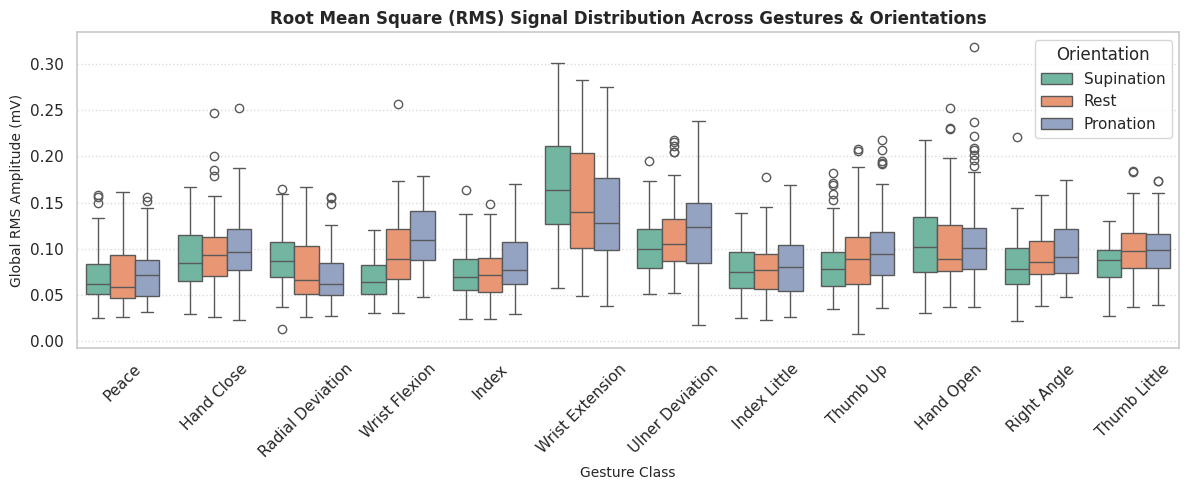

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to compute statistical summary metrics for a single file
def compute_file_stats(filepath):
    try:
        mat_dict = sio.loadmat(filepath)
        data_keys = [k for k in mat_dict.keys() if not k.startswith('__')]
        signal_key = max(data_keys, key=lambda k: mat_dict[k].size if isinstance(mat_dict[k], np.ndarray) else 0)
        signal = np.array(mat_dict[signal_key], dtype=np.float64)
        
        if signal.shape[0] < signal.shape[1]:
            signal = signal.T
            
        # Compute overall statistical metrics across channels
        return pd.Series({
            "mean_amp": np.mean(signal),
            "std_amp": np.std(signal),
            "max_amp": np.max(np.abs(signal)),
            "rms_global": np.sqrt(np.mean(signal**2))
        })
    except Exception:
        return pd.Series({
            "mean_amp": np.nan,
            "std_amp": np.nan,
            "max_amp": np.nan,
            "rms_global": np.nan
        })

print("Computing global sEMG amplitude metrics across full dataset...")

# Compute sample statistics across df_files
stats_df = df_files['filepath'].apply(compute_file_stats)
df_full = pd.concat([df_files, stats_df], axis=1)

# Display Global Summary Table grouped by Forearm Orientation
summary_table = df_full.groupby('orientation').agg(
    Files=('filename', 'count'),
    Mean_RMS=('rms_global', 'mean'),
    Std_RMS=('rms_global', 'std'),
    Max_Peak=('max_amp', 'max')
).reset_index()

print("\n" + "="*65)
print("             GLOBAL sEMG STATISTICAL SUMMARY BY ORIENTATION             ")
print("="*65)
print(summary_table.to_string(index=False))
print("="*65)

# Visualizing Global RMS Amplitude Distributions
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_full, 
    x='gesture', 
    y='rms_global', 
    hue='orientation', 
    palette='Set2'
)
plt.title("Root Mean Square (RMS) Signal Distribution Across Gestures & Orientations", fontsize=12, fontweight="bold")
plt.xlabel("Gesture Class", fontsize=10)
plt.ylabel("Global RMS Amplitude (mV)", fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(title="Orientation", loc='upper right')
plt.tight_layout()
plt.show()